In [39]:
import pandas as pd
import numpy as np
import itertools

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

In [40]:
df = pd.read_csv("MS2026023_train_var1.csv")

print(df.head())
print(df.columns)

         x1        x2        x3        x4        x5        x6          y
0 -0.249781  0.532553 -0.885346 -1.000000  1.000000  1.000000  10.598179
1 -0.879762 -0.341647 -0.759824 -0.875582 -0.740241 -0.514975  -0.647377
2 -1.000000 -0.137758  0.039648  1.000000  1.000000 -0.237724   4.273408
3  1.000000  1.000000  1.000000  1.000000  1.000000 -0.464759  -6.162812
4 -0.712977 -1.000000 -0.074035  0.219431  1.000000  1.000000   4.953501
Index(['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y'], dtype='object')


In [41]:
all_features = ['x1','x2','x3','x4','x5','x6']

y = df['y']

In [42]:
best_r2 = -999
best_mse = float('inf')

best_degree = None
best_features = None

for n_features in range(1, len(all_features)+1):

    for subset in itertools.combinations(
        all_features,
        n_features
    ):

        X = df[list(subset)]

        for degree in range(1,11):

            model = Pipeline([
                ('poly',
                 PolynomialFeatures(degree=degree)),
                ('linear',
                 LinearRegression())
            ])

            r2_scores = cross_val_score(
                model,
                X,
                y,
                cv=5,
                scoring='r2'
            )

            mse_scores = cross_val_score(
                model,
                X,
                y,
                cv=5,
                scoring='neg_mean_squared_error'
            )

            mean_r2 = r2_scores.mean()
            mean_mse = -mse_scores.mean()

            if (
                mean_r2 > best_r2
                or
                (
                    abs(mean_r2 - best_r2) < 1e-6
                    and mean_mse < best_mse
                )
            ):

                best_r2 = mean_r2
                best_mse = mean_mse

                best_degree = degree
                best_features = subset

print("\nBEST MODEL")

print("Degree =", best_degree)
print("Features =", best_features)
print("CV R2 =", best_r2)
print("CV MSE =", best_mse)


BEST MODEL
Degree = 4
Features = ('x1', 'x2', 'x3', 'x4', 'x5', 'x6')
CV R2 = 0.9261227866469216
CV MSE = 0.7568997886067317


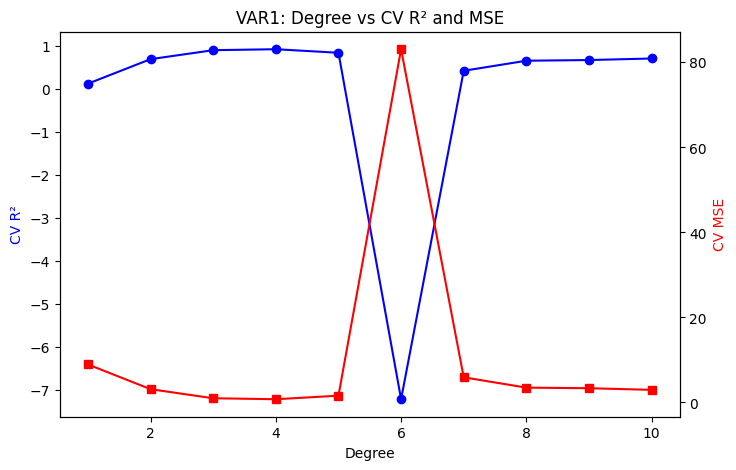

In [43]:
import matplotlib.pyplot as plt

X = df[list(best_features)]

r2_results = []
mse_results = []

for degree in range(1,11):

    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])

    r2 = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='r2'
    ).mean()

    mse = -cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='neg_mean_squared_error'
    ).mean()

    r2_results.append(r2)
    mse_results.append(mse)

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(
    range(1,11),
    r2_results,
    marker='o',
    color='blue'
)

ax1.set_xlabel("Degree")
ax1.set_ylabel("CV R²", color='blue')

ax2 = ax1.twinx()

ax2.plot(
    range(1,11),
    mse_results,
    marker='s',
    color='red'
)

ax2.set_ylabel("CV MSE", color='red')

plt.title("VAR1: Degree vs CV R² and MSE")

plt.show()

In [54]:
# VAR1 Degree Table

table_var1 = pd.DataFrame({
    'Degree': range(1,11),
    'CV_R2': np.round(r2_results, 4),
    'CV_MSE': np.round(mse_results, 4)
})

print("\nVAR1 Degree Selection Table")
print(table_var1)

table_var1.to_csv(
    "var1_degree_table.csv",
    index=False
)


VAR1 Degree Selection Table
   Degree   CV_R2   CV_MSE
0       1  0.1247   8.9432
1       2  0.6950   3.1161
2       3  0.9037   0.9831
3       4  0.9261   0.7569
4       5  0.8433   1.5862
5       6 -7.2226  83.0955
6       7  0.4241   5.9108
7       8  0.6585   3.4826
8       9  0.6740   3.3452
9      10  0.7104   2.9599


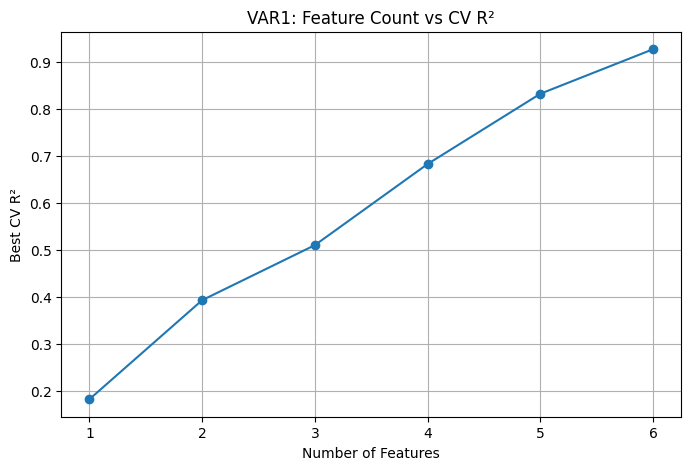

In [44]:
import itertools

feature_scores = []

features = [
    'x1','x2','x3',
    'x4','x5','x6'
]

for subset_size in range(1,7):

    best_subset_score = -999

    for subset in itertools.combinations(
        features,
        subset_size
    ):

        X = df[list(subset)]

        model = Pipeline([
            ('poly',
             PolynomialFeatures(degree=4)),
            ('linear',
             LinearRegression())
        ])

        score = cross_val_score(
            model,
            X,
            y,
            cv=5,
            scoring='r2'
        ).mean()

        best_subset_score = max(
            best_subset_score,
            score
        )

    feature_scores.append(
        best_subset_score
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(1,7),
    feature_scores,
    marker='o'
)

plt.xlabel("Number of Features")
plt.ylabel("Best CV R²")
plt.title("VAR1: Feature Count vs CV R²")

plt.grid(True)

plt.show()

In [45]:
X = df[list(best_features)]

final_model_var1 = Pipeline([
    ('poly',
     PolynomialFeatures(
         degree=best_degree
     )),
    ('linear',
     LinearRegression())
])

final_model_var1.fit(X, y)

Pipeline(steps=[('poly', PolynomialFeatures(degree=4)),
                ('linear', LinearRegression())])

In [46]:
test = pd.read_csv(
    "MS2026023_test_var1.csv"
)

X_test = test[list(best_features)]

pred = final_model_var1.predict(X_test)

In [47]:
submission = pd.DataFrame({
    'y': pred
})

submission.to_csv(
    "MS2026023_pred_var1.csv",
    index=False
)

In [48]:
df = pd.read_csv(
    "MS2026023_train_var2.csv"
)

all_features = ['x1','x2','x3']
y = df['y']

In [49]:
best_r2 = -999
best_mse = float('inf')

best_degree = None
best_features = None

for n_features in range(1,4):

    for subset in itertools.combinations(
        all_features,
        n_features
    ):

        X = df[list(subset)]

        for degree in range(1,21):

            model = Pipeline([
                ('poly',
                 PolynomialFeatures(
                     degree=degree
                 )),
                ('linear',
                 LinearRegression())
            ])

            r2_scores = cross_val_score(
                model,
                X,
                y,
                cv=5,
                scoring='r2'
            )

            mse_scores = cross_val_score(
                model,
                X,
                y,
                cv=5,
                scoring='neg_mean_squared_error'
            )

            mean_r2 = r2_scores.mean()
            mean_mse = -mse_scores.mean()

            if (
                mean_r2 > best_r2
                or
                (
                    abs(mean_r2 - best_r2) < 1e-6
                    and mean_mse < best_mse
                )
            ):

                best_r2 = mean_r2
                best_mse = mean_mse

                best_degree = degree
                best_features = subset

print("\nBEST MODEL")

print("Degree =", best_degree)
print("Features =", best_features)
print("CV R2 =", best_r2)
print("CV MSE =", best_mse)


BEST MODEL
Degree = 8
Features = ('x1', 'x2', 'x3')
CV R2 = 0.9937882955633685
CV MSE = 0.3063820449439411


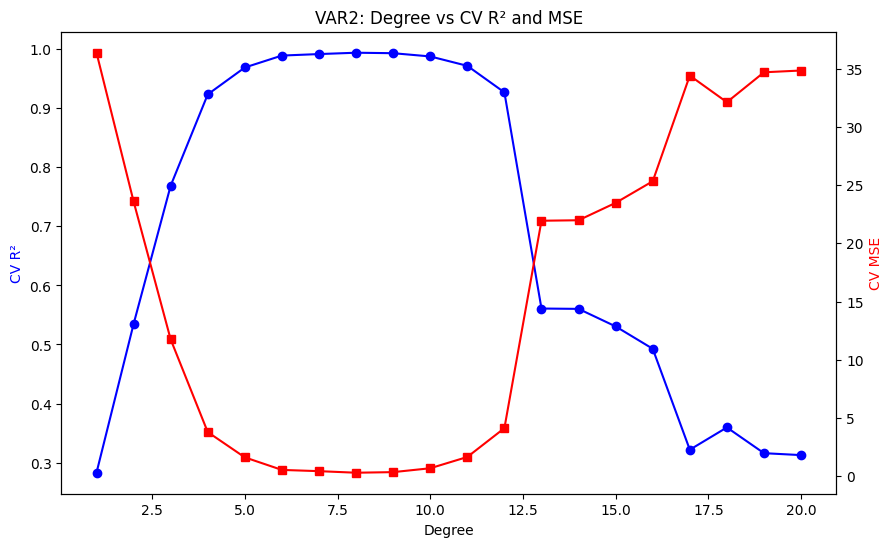

In [50]:
best_degree_scores = []
best_degree_mse = []

for degree in range(1,21):

    best_r2_deg = -999
    best_mse_deg = None

    for subset_size in range(1,4):

        for subset in itertools.combinations(
            all_features,
            subset_size
        ):

            X = df[list(subset)]

            model = Pipeline([
                ('poly',
                 PolynomialFeatures(
                     degree=degree
                 )),
                ('linear',
                 LinearRegression())
            ])

            r2 = cross_val_score(
                model,
                X,
                y,
                cv=5,
                scoring='r2'
            ).mean()

            mse = -cross_val_score(
                model,
                X,
                y,
                cv=5,
                scoring='neg_mean_squared_error'
            ).mean()

            if r2 > best_r2_deg:

                best_r2_deg = r2
                best_mse_deg = mse

    best_degree_scores.append(
        best_r2_deg
    )

    best_degree_mse.append(
        best_mse_deg
    )

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(
    range(1,21),
    best_degree_scores,
    marker='o',
    color='blue'
)

ax1.set_xlabel("Degree")
ax1.set_ylabel("CV R²", color='blue')

ax2 = ax1.twinx()

ax2.plot(
    range(1,21),
    best_degree_mse,
    marker='s',
    color='red'
)

ax2.set_ylabel("CV MSE", color='red')

plt.title("VAR2: Degree vs CV R² and MSE")

plt.show()

In [55]:
# VAR2 Degree Table

table_var2 = pd.DataFrame({
    'Degree': range(1,21),
    'CV_R2': np.round(best_degree_scores, 4),
    'CV_MSE': np.round(best_degree_mse, 4)
})

print("\nVAR2 Degree Selection Table")
print(table_var2)

table_var2.to_csv(
    "var2_degree_table.csv",
    index=False
)


VAR2 Degree Selection Table
    Degree   CV_R2   CV_MSE
0        1  0.2830  36.3604
1        2  0.5346  23.5958
2        3  0.7687  11.7508
3        4  0.9233   3.7950
4        5  0.9688   1.6247
5        6  0.9890   0.5476
6        7  0.9915   0.4404
7        8  0.9938   0.3064
8        9  0.9930   0.3574
9       10  0.9875   0.6902
10      11  0.9716   1.6582
11      12  0.9267   4.1316
12      13  0.5609  21.9378
13      14  0.5603  21.9789
14      15  0.5306  23.4727
15      16  0.4928  25.3263
16      17  0.3219  34.3961
17      18  0.3596  32.1149
18      19  0.3161  34.6812
19      20  0.3128  34.8332


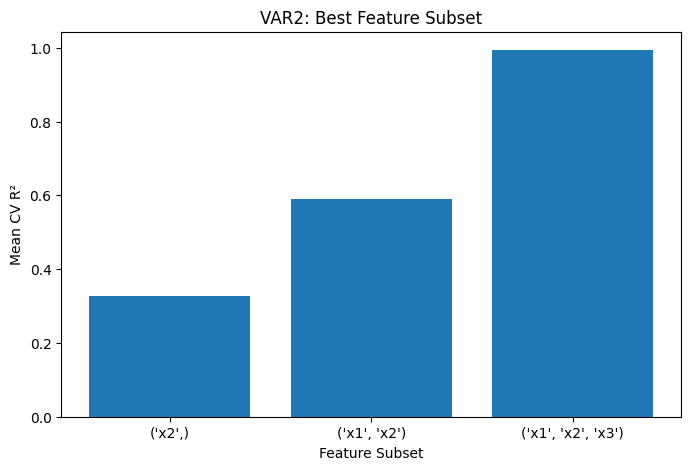

In [51]:
feature_scores = []
feature_labels = []

for subset_size in range(1,4):

    best_subset_score = -999
    best_subset = None

    for subset in itertools.combinations(
        all_features,
        subset_size
    ):

        X = df[list(subset)]

        model = Pipeline([
            ('poly',
             PolynomialFeatures(
                 degree=best_degree
             )),
            ('linear',
             LinearRegression())
        ])

        score = cross_val_score(
            model,
            X,
            y,
            cv=5,
            scoring='r2'
        ).mean()

        if score > best_subset_score:

            best_subset_score = score
            best_subset = subset

    feature_scores.append(
        best_subset_score
    )

    feature_labels.append(
        str(best_subset)
    )

plt.figure(figsize=(8,5))

plt.bar(
    feature_labels,
    feature_scores
)

plt.ylabel("Mean CV R²")
plt.xlabel("Feature Subset")

plt.title(
    "VAR2: Best Feature Subset"
)

plt.show()

In [52]:
X = df[list(best_features)]

final_model_var2 = Pipeline([
    ('poly',
     PolynomialFeatures(
         degree=best_degree
     )),
    ('linear',
     LinearRegression())
])

final_model_var2.fit(X, y)

Pipeline(steps=[('poly', PolynomialFeatures(degree=8)),
                ('linear', LinearRegression())])

In [53]:
test = pd.read_csv(
    "MS2026023_test_var2.csv"
)

X_test = test[list(best_features)]

pred = final_model_var2.predict(X_test)

pd.DataFrame({
    'y': pred
}).to_csv(
    "MS2026023_pred_var2.csv",
    index=False
)